# Projet1: la Détection de fraudes financières

## Contenue
### Introduction
- 1-Load packages (télécharger les Bibliothèques)
- 2-Read the data (Lire les données)
- 3-Feature Engeniering (Vérification)
    - Check missing data (Variables manquantes)
    - Check data unbalance (équilibrage des variables)
    - Data quality (Extraire la qualité des données)
- 4-Data exploration (EDA)
- 5-Predictive models (Modèle prédictifs)
    - LogisticRegression
    - RandomForrestClassifier
    - AdaBoostClassifier
    - CatBoostClassifier
    - XGBoost
    - LightGBM
### Conclusions
### Références

# Introduction

Le projet porte sur la **détection de fraudes sur les cartes de crédit** à partir d’un **jeu de données réel** collecté en **septembre 2013** auprès de titulaires européens.
Il contient les transactions effectuées sur **deux jours**, dont **492 sont frauduleuses** sur un total de **284 807 transactions**.
Le dataset est donc **très déséquilibré**, car les fraudes représentent seulement **0,172 %** de l’ensemble.


### **Caractéristiques clés du projet :**

1. **Type de données :**

   * Données **numériques uniquement**, issues d’une **transformation PCA** (V1 à V28).
   * Les seules variables non transformées sont **Time** et **Amount**.

2. **Variables importantes :**

   * **Time :** secondes écoulées depuis la première transaction.
   * **Amount :** montant de la transaction.
   * **Class :** variable cible (1 = fraude, 0 = non fraude).

3. **Problématique principale :**

   * **Forte déséquilibration des classes** (très peu de fraudes par rapport au total).


## 1-Load Packages

In [16]:
# Load Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

## 2-Read the Data

In [ ]:
# Bibliothèque
#!pip install kagglehub
import kagglehub
# Télécharger la dernière version du dataset
# web: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Path to dataset files:", path)

100%|██████████| 66.0M/66.0M [00:26<00:00, 2.61MB/s]

Extracting files...


Path to dataset files: C:\Users\wilfr\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3


In [12]:
import os
# Affiche les fichiers disponibles dans le dossier téléchargé
print(os.listdir(path))

['creditcard.csv']


In [13]:
import pandas as pd
# Exemple : charger le premier fichier CSV du dossier
df = pd.read_csv(os.path.join(path, "creditcard.csv"))  # adapte le nom du fichier si différent
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

## 3- Feature Engeniering

In [19]:
# Afficher les informations sur le DataFrame
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [21]:
 # Afficher les statistiques descriptives
print(df.describe())

                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15   
std    1.380247e+00  1.332271e+00  1.23709

In [22]:
# Vérifier les valeurs manquantes
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


Class
0    284315
1       492
Name: count, dtype: int64


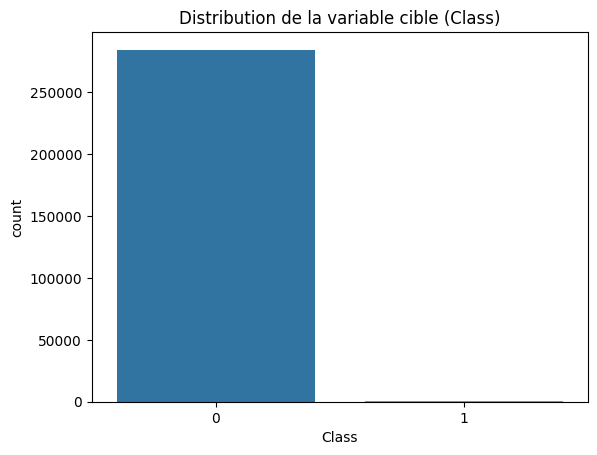

In [23]:
# Vérifier la distribution de la variable cible
print(df['Class'].value_counts())
# Visualiser la distribution de la variable cible
sns.countplot(x='Class', data=df)
plt.title('Distribution de la variable cible (Class)')
plt.show()

## 4-Data Exploaration (EDA)

### 4.1 Time

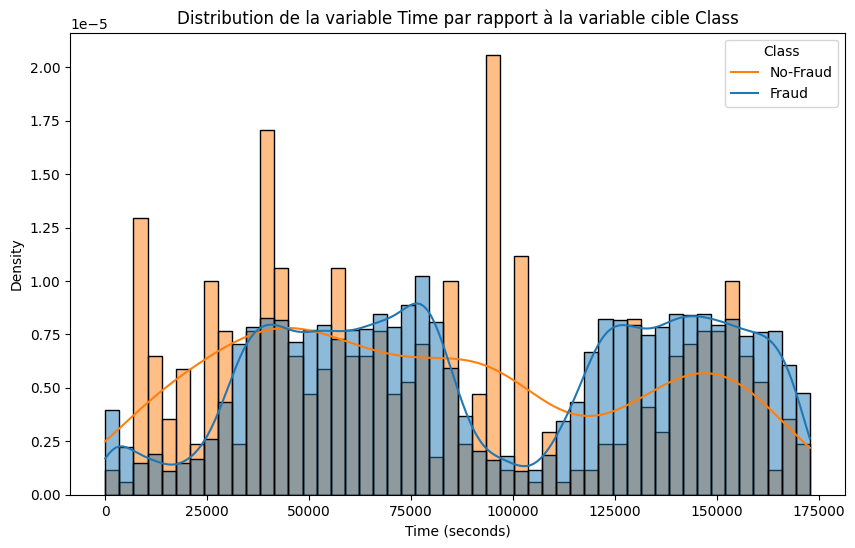

In [26]:
# Analysons la variable 'Time' avec la variable cible 'Class'
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Time', hue='Class', bins=50, kde=True, stat="density", common_norm=False)
plt.title('Distribution de la variable Time par rapport à la variable cible Class')
plt.xlabel('Time (seconds)')
plt.ylabel('Density')
plt.legend(title='Class', labels=['No-Fraud', 'Fraud'])
plt.show()